In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [6]:
rolls = np.random.randint(1, 21, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.8)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.498  (true 0.8)
P(>4)   ~ 0.799  (true 0.333)


In [7]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1)+P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3),'-> they match')

P(1) + P(2) = 0.101
P(1 or 2)   = 0.101  -> they match


In [8]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

p_both_heads = np.mean(heads == 2)
print("--- Probability Estimates ---")
print(f"P(both heads):          {p_both_heads:.4f}  (Theoretical: 0.25)")

p_at_least_one_head = np.mean(heads >= 1)
print(f"P(at least one head):   {p_at_least_one_head:.4f}  (Theoretical: 0.75)")

p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

total_probability = p_0 + p_1 + p_2

print(f"\n--- Addition Check ---")
print(f"P(0 heads): {p_0:.4f}")
print(f"P(1 head):  {p_1:.4f}")
print(f"P(2 heads): {p_2:.4f}")
print(f"Sum of all outcomes: {total_probability:.4f}")
print(f"Does it sum to 1? {np.isclose(total_probability, 1.0)}")


--- Probability Estimates ---
P(both heads):          0.2492  (Theoretical: 0.25)
P(at least one head):   0.7498  (Theoretical: 0.75)

--- Addition Check ---
P(0 heads): 0.2502
P(1 head):  0.5006
P(2 heads): 0.2492
Sum of all outcomes: 1.0000
Does it sum to 1? True


In [9]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.333  (true 1/3)


In [10]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.499
P(A | B)  = 0.667
Independent? False


In [11]:
rolls = np.random.randint(1, 7, size=100_000)

rolls_less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = np.mean(rolls_less_than_4 % 2 != 0)

print("--- Conditional & Overall Probabilities ---")
print(f"P(roll is odd | roll < 4): {p_odd_given_less_than_4:.4f}  (Theoretical: 2/3 ≈ 0.6667)")

p_less_than_4 = np.mean(rolls < 4)
print(f"P(roll < 4) overall:        {p_less_than_4:.4f}  (Theoretical: 3/6 = 0.5000)")

p_odd_overall = np.mean(rolls % 2 != 0)
is_independent = np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.01)

print(f"\n--- Independence Check ---")
print(f"P(odd | roll < 4) = {p_odd_given_less_than_4:.4f}")
print(f"P(odd) overall    = {p_odd_overall:.4f}  (Theoretical: 3/6 = 0.5000)")
print(f"Are the events independent? {is_independent}")
print("Reason: They are NOT independent because knowing that the roll is less than 4 changes the probability of getting an odd number from 50% to roughly 66.67%.")


--- Conditional & Overall Probabilities ---
P(roll is odd | roll < 4): 0.6668  (Theoretical: 2/3 ≈ 0.6667)
P(roll < 4) overall:        0.4983  (Theoretical: 3/6 = 0.5000)

--- Independence Check ---
P(odd | roll < 4) = 0.6668
P(odd) overall    = 0.4973  (Theoretical: 3/6 = 0.5000)
Are the events independent? False
Reason: They are NOT independent because knowing that the roll is less than 4 changes the probability of getting an odd number from 50% to roughly 66.67%.


In [12]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

p_D_given_pos = (p_pos_given_D * p_disease) / p_pos

print(f"Total probability of a positive test P(+): {p_pos:.4f}")
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


Total probability of a positive test P(+): 0.0198
P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [13]:
import numpy as np
p_disease = 0.01
p_pos_given_D = 0.99
p_pos_given_nD = 0.01

N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.507


In [14]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

print("--- Total Probability ---")
print(f"P('free'): {p_free:.3f}")

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("\n--- Posterior Probability (Bayes) ---")
print(f"P(spam | 'free') = {p_spam_given_free:.3f}")
print(f"-> Your confidence that it's spam jumped from {p_spam*100:.0f}% (prior) to {p_spam_given_free*100:.1f}% because it contains 'free'.")


--- Total Probability ---
P('free'): 0.160

--- Posterior Probability (Bayes) ---
P(spam | 'free') = 0.750
-> Your confidence that it's spam jumped from 20% (prior) to 75.0% because it contains 'free'.


In [16]:
from scipy import stats
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.305 (true 0.3)
Poisson(4) mean ~ 4.021 (true 4)


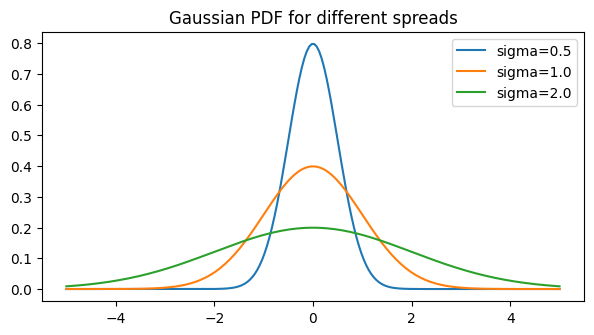

In [17]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

--- Poisson Sampling ---
Poisson(2) sample mean: 2.0123 (True mean: 2.0)


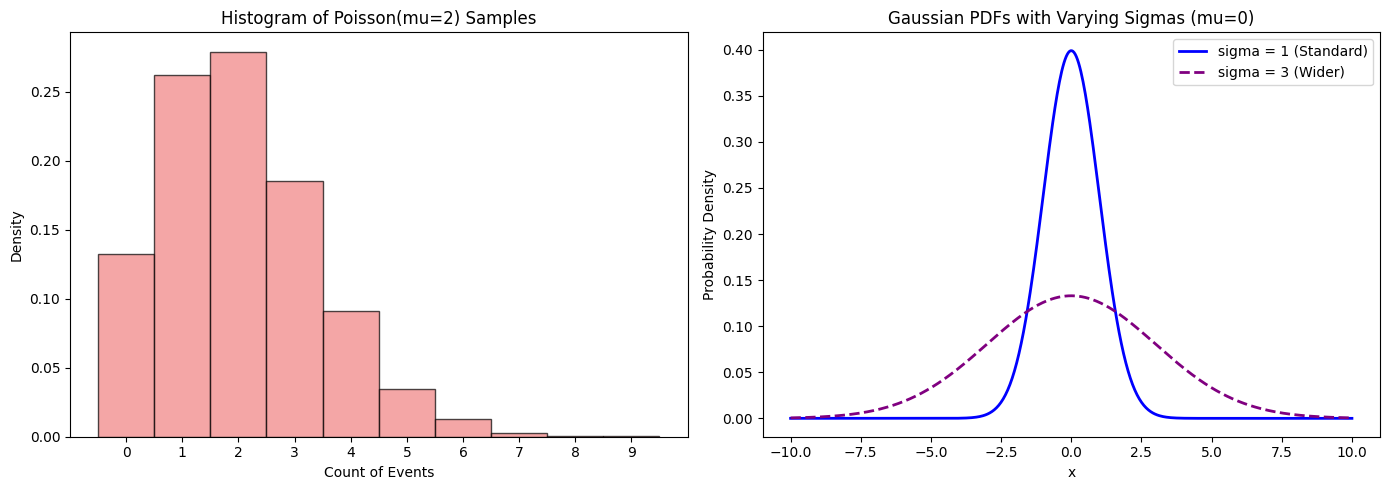

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pois_samples = stats.poisson(mu=2).rvs(size=10_000)
print("--- Poisson Sampling ---")
print(f"Poisson(2) sample mean: {pois_samples.mean():.4f} (True mean: 2.0)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pois_samples, bins=np.arange(pois_samples.min(), pois_samples.max() + 2) - 0.5,
             density=True, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram of Poisson(mu=2) Samples', fontsize=12)
axes[0].set_xlabel('Count of Events', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].set_xticks(range(pois_samples.min(), pois_samples.max() + 1))

x = np.linspace(-10, 10, 500)

pdf_sigma_1 = stats.norm(loc=0, scale=1).pdf(x)
axes[1].plot(x, pdf_sigma_1, color='blue', linewidth=2, label='sigma = 1 (Standard)')

pdf_sigma_3 = stats.norm(loc=0, scale=3).pdf(x)
axes[1].plot(x, pdf_sigma_3, color='purple', linewidth=2, linestyle='--', label='sigma = 3 (Wider)')

axes[1].set_title('Gaussian PDFs with Varying Sigmas (mu=0)', fontsize=12)
axes[1].set_xlabel('x', fontsize=10)
axes[1].set_ylabel('Probability Density', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]

print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [20]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [21]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [25]:
import numpy as np
from scipy import stats
prob_4=[1/4]*4
prob_6=[1/5]*6

entropy_4=stats.entropy(prob_4,base=2)
entropy_6=stats.entropy(prob_4,base=6)
print("---Entropy Calculations---")
print(f"entropy of 4 sided die: {entropy_4:.4f} bits")
print(f"entropy of 6 sided die: {entropy_6:.4f} bits")
print(f"Which is more uncertain? The 6-sided die is more uncertain because it has higher entropy.")

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl_div = stats.entropy(P, Q, base=2)

print("\n--- KL Divergence ---")
print(f"D(P || Q): {kl_div:.4f} bits")





---Entropy Calculations---
entropy of 4 sided die: 2.0000 bits
entropy of 6 sided die: 0.7737 bits
Which is more uncertain? The 6-sided die is more uncertain because it has higher entropy.

--- KL Divergence ---
D(P || Q): 0.1187 bits
